In [1]:
#if running for first time, or running on colab, uncomment next lines
# !pip install pepit==0.5.0

## Examples: simple comparisons between gradient descent, Nesterov acceleration, and an heavy-ball method

In this notebook, we consider the convex minimization problem

$$ \min_x f(x),$$

where $f$ is assumed to be convex and $L$-smooth. We compare three methods based on different criterion, and illustrate that:
- the precise choice of the criterion plays in important role in the convergence rate. It might even change the prescribed performance ordering of the algorithms.
- It might not be worth fighting for *tight* closed-form performance bounds, as they might be highly nontrivial, and as the transient behaviors might not carry much information.

The thee methods under consideration here are:

- vanilla gradient descent:

$$x_{k+1}=x_k-\tfrac1L\nabla f(x_k),$$

- an heavy-ball method:
\begin{equation*}
\begin{aligned}
x_{k+1} = x_k - \alpha \nabla f(x_k) + \beta (x_k - x_{k-1})
\end{aligned}
\end{equation*}
choice here: $\alpha = \tfrac{1}{2L}$, $\beta=\sqrt{1 - L\alpha}$, as studied in [1],

- a classical variation of Nesterov's accelerated gradient method [2]:
\begin{equation*}
\begin{aligned}
x_{k+1} &= y_k - \tfrac1L \nabla f(x_k)\\
y_{k+1} &= x_{k+1}+\tfrac{k-1}{k+1}(x_{k+1} - x_{k}).
\end{aligned}
\end{equation*}

---
**References.**

[1] E. Ghadimi, H.R. Feyzmahdavian and M. Johansson, *Global convergence of the Heavy-ball method for convex optimization*, European control conference (ECC), 2015. [arXiv:1412.7457](https://arxiv.org/abs/1412.7457)


[2] Y. Nesterov, *A method of solving a convex programming problem with convergence rate $O(1/k^2)$*, Doklady Akademii Nauk SSSR, 1983. [English translation](https://github.com/PerformanceEstimation/Tutorial-SMAI-MODE/References/1983_Nesterov.pdf)

<a id="toc"></a>
## Table of Contents

1. [Worst-case perfomance in terms of $({f(x_n)-f_\star})/{\|x_0-x_\star\|^2}$](#sec1)
2. [Worst-case perfomance in terms of $({\|\nabla f(x_n)\|^2})/{\|x_0-x_\star\|^2}$](#sec2)
3. [Worst-case perfomance in terms of $({\min_{0\leq k \leq n} \|\nabla f(x_n)\|^2})/{\|x_0-x_\star\|^2}$](#sec3)

### 1. Worst-case perfomance in terms of $\frac{f(x_n)-f_\star}{\|x_0-x_\star\|^2}$  <a class="anchor" id="sec1"></a>

In [9]:
from PEPit import PEP
from PEPit.functions import SmoothConvexFunction
from math import sqrt

def wc_gradient_descent(L, n):

    gamma = 1/L
    # Instantiate PEP
    problem = PEP()

    # Declare a smooth convex function
    f = problem.declare_function(SmoothConvexFunction, L=L)

    # Start by defining its unique optimal point xs = x_* and corresponding function value fs = f_*
    xs = f.stationary_point()
    fs = f(xs)

    # Then define the starting point x0 of the algorithm
    x0 = problem.set_initial_point()

    # Set the initial constraint that is the distance between x0 and x^*
    problem.set_initial_condition((x0 - xs) ** 2 <= 1)

    # Run n steps of the GD method
    x = x0
    for _ in range(n):
        x = x - gamma * f.gradient(x)

    # Set the performance metric to the function values accuracy
    problem.set_performance_metric( f(x)-fs)

    # Solve the PEP
    pepit_verbose = 0
    pepit_tau = problem.solve(verbose=pepit_verbose)

    # Return the worst-case guarantee of the evaluated method 
    return pepit_tau

def wc_heavy_ball_momentum(L, n):
    
    alpha = .5/L
    beta = sqrt((1 - L*alpha))
    # Instantiate PEP
    problem = PEP()

    # Declare a smooth strongly convex function
    f = problem.declare_function(SmoothConvexFunction, L=L)

    # Start by defining its unique optimal point xs = x_* and corresponding function value fs = f_*
    xs = f.stationary_point()
    fs = f(xs)

    # Then define the starting point x0 of the algorithm as well as corresponding function value f0
    x0 = problem.set_initial_point()
    f0 = f(x0)

    # Set the initial constraint that is the distance between f(x0) and f(x^*)
    problem.set_initial_condition((x0-xs)**2 <= 1)

    # Run one step of the heavy ball method
    x_new = x0
    x_old = x0

    for _ in range(n):
        x_next = x_new - alpha * f.gradient(x_new) + beta * (x_new - x_old)
        x_old = x_new
        x_new = x_next

    # Set the performance metric to the final distance to optimum
    problem.set_performance_metric( f(x_new)-fs )

    # Solve the PEP
    pepit_verbose = 0
    pepit_tau = problem.solve(verbose=pepit_verbose)
    
    # Return the worst-case guarantee of the evaluated method
    return pepit_tau

def wc_accelerated_gradient_convex(L, n):
    
    # Instantiate PEP
    problem = PEP()

    # Declare a strongly convex smooth function
    f = problem.declare_function(SmoothConvexFunction, L=L)

    # Start by defining its unique optimal point xs = x_* and corresponding function value fs = f_*
    xs = f.stationary_point()
    fs = f(xs)

    # Then define the starting point x0 of the algorithm
    x0 = problem.set_initial_point()

    # Set the initial constraint that is the distance between x0 and x^*
    problem.set_initial_condition((x0 - xs) ** 2 <= 1)

    # Run n steps of the fast gradient method
    x_new = x0
    y = x0
    for i in range(n):
        x_old = x_new
        x_new = y - 1 / L * f.gradient(y)
        y = x_new + i / (i + 3) * (x_new - x_old)

    # Set the performance metric to the function value accuracy
    problem.set_performance_metric( f(y)-fs )

    # Solve the PEP
    pepit_verbose = 0
    pepit_tau = problem.solve(verbose=pepit_verbose)

    # Return the worst-case guarantee of the evaluated method (and the reference theoretical value)
    return pepit_tau

In [10]:
# Execute for different parameters
import matplotlib.pyplot as plt
import numpy as np
import time

L = 1
n_list = np.array([1, 2, 3, 4, 5, 6, 7, 8, 10, 15, 20, 25, 30, 40])

pepit_taus_GD = list()
pepit_taus_HB = list()
pepit_taus_AGD = list()

count = 0
for n in n_list:
    pepit_taus_GD.append(wc_gradient_descent(L, n))
    pepit_taus_HB.append(wc_heavy_ball_momentum(L, n))
    pepit_taus_AGD.append(wc_accelerated_gradient_convex(L, n))
    count += 1
    print(f'{count} / {len(n_list)} points computed', end='\r', flush=True)
print("done!                          ")


done!                          


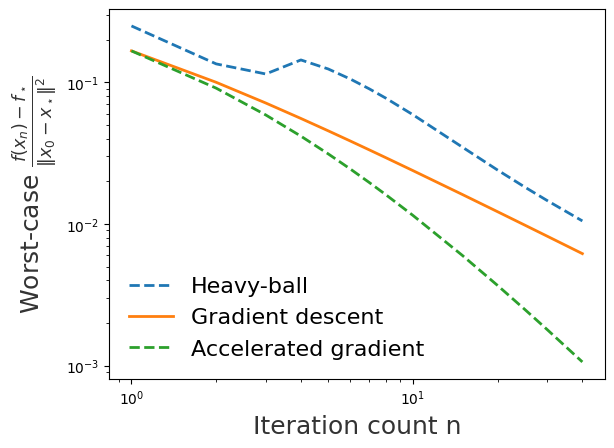

In [12]:
# Create figure and axes
fig, ax = plt.subplots()

# Plot the data

ax.plot(n_list, pepit_taus_HB, '--', label='Heavy-ball', linewidth=2)
ax.plot(n_list, pepit_taus_GD, '-', label='Gradient descent', linewidth=2)
ax.plot(n_list, pepit_taus_AGD, '--', label='Accelerated gradient', linewidth=2)

# Add legend, labels, and configure log-log scale
legend = ax.legend(fontsize=16)
legend.get_frame().set_facecolor('none')  # Make the legend box background transparent
legend.get_frame().set_edgecolor('none')  # Make the legend box border transparent

ax.set_xscale('log')
ax.set_yscale('log')

ax.set_xlabel('Iteration count n', labelpad=5, color='#333333', fontsize = 18)
ax.set_ylabel(r'Worst-case $\frac{f(x_n)-f_\star}{\|x_0-x_\star\|^2}$', labelpad=5, color='#333333',fontsize = 18)

# Save the figure before displaying it
plt.savefig(fname='func_values.eps', format='eps')

# Show the plot
plt.show()

### 2. Worst-case perfomance in terms of $\frac{\|\nabla f(x_n)\|^2}{\|x_0-x_\star\|^2}$  <a class="anchor" id="sec2"></a>

In [13]:
from PEPit import PEP
from PEPit.functions import SmoothConvexFunction
from math import sqrt

def wc_gradient_descent(L, n):

    gamma = 1/L
    # Instantiate PEP
    problem = PEP()

    # Declare a smooth convex function
    f = problem.declare_function(SmoothConvexFunction, L=L)

    # Start by defining its unique optimal point xs = x_* and corresponding function value fs = f_*
    xs = f.stationary_point()
    fs = f(xs)

    # Then define the starting point x0 of the algorithm
    x0 = problem.set_initial_point()

    # Set the initial constraint that is the distance between x0 and x^*
    problem.set_initial_condition((x0 - xs) ** 2 <= 1)

    # Run n steps of the GD method
    x = x0
    for _ in range(n):
        x = x - gamma * f.gradient(x)

    # Set the performance metric to the function values accuracy
    problem.set_performance_metric( f.gradient(x)**2 )

    # Solve the PEP
    pepit_verbose = 0
    pepit_tau = problem.solve(verbose=pepit_verbose)

    # Return the worst-case guarantee of the evaluated method 
    return pepit_tau

def wc_heavy_ball_momentum(L, n):
    
    alpha = .5/L
    beta = sqrt((1 - L*alpha))
    # Instantiate PEP
    problem = PEP()

    # Declare a smooth strongly convex function
    f = problem.declare_function(SmoothConvexFunction, L=L)

    # Start by defining its unique optimal point xs = x_* and corresponding function value fs = f_*
    xs = f.stationary_point()
    fs = f(xs)

    # Then define the starting point x0 of the algorithm as well as corresponding function value f0
    x0 = problem.set_initial_point()
    f0 = f(x0)

    # Set the initial constraint that is the distance between f(x0) and f(x^*)
    problem.set_initial_condition((x0-xs)**2 <= 1)

    # Run one step of the heavy ball method
    x_new = x0
    x_old = x0

    for _ in range(n):
        x_next = x_new - alpha * f.gradient(x_new) + beta * (x_new - x_old)
        x_old = x_new
        x_new = x_next

    # Set the performance metric to the final distance to optimum
    problem.set_performance_metric( f.gradient(x_new)**2)

    # Solve the PEP
    pepit_verbose = 0
    pepit_tau = problem.solve(verbose=pepit_verbose)
    
    # Return the worst-case guarantee of the evaluated method
    return pepit_tau

def wc_accelerated_gradient_convex(L, n):
    
    # Instantiate PEP
    problem = PEP()

    # Declare a strongly convex smooth function
    f = problem.declare_function(SmoothConvexFunction, L=L)

    # Start by defining its unique optimal point xs = x_* and corresponding function value fs = f_*
    xs = f.stationary_point()
    fs = f(xs)

    # Then define the starting point x0 of the algorithm
    x0 = problem.set_initial_point()

    # Set the initial constraint that is the distance between x0 and x^*
    problem.set_initial_condition((x0 - xs) ** 2 <= 1)

    # Run n steps of the fast gradient method
    x_new = x0
    y = x0
    for i in range(n):
        x_old = x_new
        x_new = y - 1 / L * f.gradient(y)
        y = x_new + i / (i + 3) * (x_new - x_old)

    # Set the performance metric to the function value accuracy
    problem.set_performance_metric( f.gradient(y)**2 )

    # Solve the PEP
    pepit_verbose = 0
    pepit_tau = problem.solve(verbose=pepit_verbose)

    # Return the worst-case guarantee of the evaluated method (and the reference theoretical value)
    return pepit_tau

In [14]:
# Execute for different parameters
import matplotlib.pyplot as plt
import numpy as np
import time

L = 1
n_list = np.array([1, 2, 3, 4, 5, 6, 7, 8, 10, 15, 20, 25, 30, 40])

pepit_taus_GD = list()
pepit_taus_HB = list()
pepit_taus_AGD = list()

count = 0
for n in n_list:
    
    pepit_taus_GD.append(wc_gradient_descent(L, n))
    pepit_taus_HB.append(wc_heavy_ball_momentum(L, n))
    pepit_taus_AGD.append(wc_accelerated_gradient_convex(L, n))
    count += 1
    print(f'{count} / {len(n_list)} points computed', end='\r', flush=True)
print("done!                          ")


done!                          


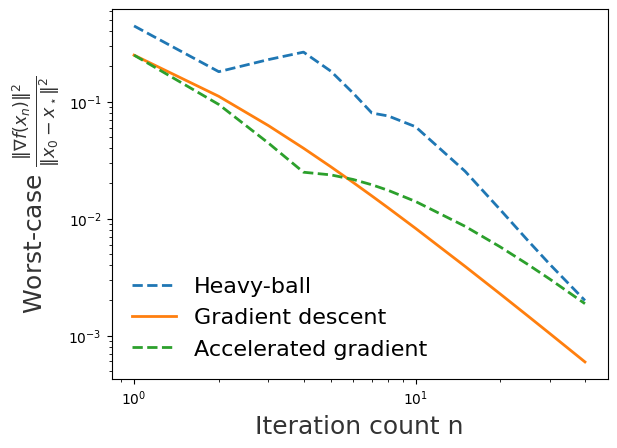

In [16]:
# Create figure and axes
fig, ax = plt.subplots()

# Plot the data

ax.plot(n_list, pepit_taus_HB, '--', label='Heavy-ball', linewidth=2)
ax.plot(n_list, pepit_taus_GD, '-', label='Gradient descent', linewidth=2)
ax.plot(n_list, pepit_taus_AGD, '--', label='Accelerated gradient', linewidth=2)

# Add legend, labels, and configure log-log scale
legend = ax.legend(fontsize=16)
legend.get_frame().set_facecolor('none')  # Make the legend box background transparent
legend.get_frame().set_edgecolor('none')  # Make the legend box border transparent

ax.set_xscale('log')
ax.set_yscale('log')

ax.set_xlabel('Iteration count n', labelpad=5, color='#333333', fontsize = 18)
ax.set_ylabel(r'Worst-case $\frac{\|\nabla f(x_n)\|^2}{\|x_0-x_\star\|^2}$', labelpad=5, color='#333333',fontsize = 18)

# Save the figure before displaying it
plt.savefig(fname='grad_values.eps', format='eps')

# Show the plot
plt.show()

### 3. Worst-case perfomance in terms of $\frac{\min_{0\leq k \leq n} \|\nabla f(x_n)\|^2}{\|x_0-x_\star\|^2}$  <a class="anchor" id="sec3"></a>

In [17]:
from PEPit import PEP
from PEPit.functions import SmoothConvexFunction
from math import sqrt

def wc_best_gradient_descent(L, n):

    gamma = 1/L
    # Instantiate PEP
    problem = PEP()

    # Declare a smooth convex function
    f = problem.declare_function(SmoothConvexFunction, L=L)

    # Start by defining its unique optimal point xs = x_* and corresponding function value fs = f_*
    xs = f.stationary_point()
    fs = f(xs)

    # Then define the starting point x0 of the algorithm
    x0 = problem.set_initial_point()

    # Set the initial constraint that is the distance between x0 and x^*
    problem.set_initial_condition((x0 - xs) ** 2 <= 1)

    # Run n steps of the GD method
    x = x0
    problem.set_performance_metric( f.gradient(x)**2 )
    for _ in range(n):
        x = x - gamma * f.gradient(x)
        problem.set_performance_metric( f.gradient(x)**2 )

    # Set the performance metric to the function values accuracy

    # Solve the PEP
    pepit_verbose = 0
    pepit_tau = problem.solve(verbose=pepit_verbose)

    # Return the worst-case guarantee of the evaluated method 
    return pepit_tau

def wc_best_heavy_ball_momentum(L, n):
    
    alpha = .5/L
    beta = sqrt((1 - L*alpha))
    # Instantiate PEP
    problem = PEP()

    # Declare a smooth strongly convex function
    f = problem.declare_function(SmoothConvexFunction, L=L)

    # Start by defining its unique optimal point xs = x_* and corresponding function value fs = f_*
    xs = f.stationary_point()
    fs = f(xs)

    # Then define the starting point x0 of the algorithm as well as corresponding function value f0
    x0 = problem.set_initial_point()
    f0 = f(x0)

    # Set the initial constraint that is the distance between f(x0) and f(x^*)
    problem.set_initial_condition((x0-xs)**2 <= 1)

    # Run one step of the heavy ball method
    x_new = x0
    x_old = x0
    problem.set_performance_metric( f.gradient(x_new)**2)
    for _ in range(n):
        x_next = x_new - alpha * f.gradient(x_new) + beta * (x_new - x_old)
        x_old = x_new
        x_new = x_next
        problem.set_performance_metric( f.gradient(x_new)**2)

    # Set the performance metric to the final distance to optimum
    

    # Solve the PEP
    pepit_verbose = 0
    pepit_tau = problem.solve(verbose=pepit_verbose)
    
    # Return the worst-case guarantee of the evaluated method
    return pepit_tau

def wc_best_accelerated_gradient_convex(L, n):
    
    # Instantiate PEP
    problem = PEP()

    # Declare a strongly convex smooth function
    f = problem.declare_function(SmoothConvexFunction, L=L)

    # Start by defining its unique optimal point xs = x_* and corresponding function value fs = f_*
    xs = f.stationary_point()
    fs = f(xs)

    # Then define the starting point x0 of the algorithm
    x0 = problem.set_initial_point()

    # Set the initial constraint that is the distance between x0 and x^*
    problem.set_initial_condition((x0 - xs) ** 2 <= 1)

    # Run n steps of the fast gradient method
    x_new = x0
    y = x0
    problem.set_performance_metric( f.gradient(y)**2 )
    for i in range(n):
        x_old = x_new
        x_new = y - 1 / L * f.gradient(y)
        y = x_new + i / (i + 3) * (x_new - x_old)
        problem.set_performance_metric( f.gradient(y)**2 )

    # Set the performance metric to the function value accuracy
    

    # Solve the PEP
    pepit_verbose = 0
    pepit_tau = problem.solve(verbose=pepit_verbose)

    # Return the worst-case guarantee of the evaluated method (and the reference theoretical value)
    return pepit_tau

In [18]:
# Execute for different parameters
import matplotlib.pyplot as plt
import numpy as np
import time

L = 1
n_list = np.array([1, 2, 3, 4, 5, 6, 7, 8, 10, 15, 20, 25, 30, 40])

pepit_taus_best_GD = list()
pepit_taus_best_HB = list()
pepit_taus_best_AGD = list()

count = 0
for n in n_list:
    
    pepit_taus_best_GD.append(wc_best_gradient_descent(L, n))
    pepit_taus_best_HB.append(wc_best_heavy_ball_momentum(L, n))
    pepit_taus_best_AGD.append(wc_best_accelerated_gradient_convex(L, n))
    count += 1
    print(f'{count} / {len(n_list)} points computed', end='\r', flush=True)
print("done!                          ")


done!                          


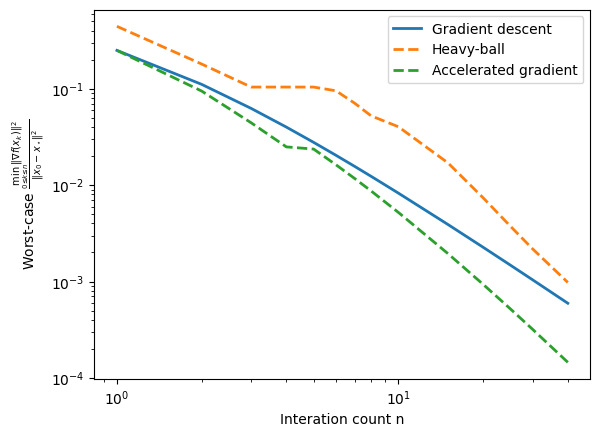

In [20]:
# Plots
plt.plot(n_list, pepit_taus_best_GD, '-', label='Gradient descent', linewidth=2)
plt.plot(n_list, pepit_taus_best_HB, '--', label='Heavy-ball', linewidth=2)
plt.plot(n_list, pepit_taus_best_AGD, '--', label='Accelerated gradient', linewidth=2)

plt.legend()
plt.xlabel('Interation count n')
plt.ylabel(r'Worst-case $\frac{\min_{0\leq k\leq n}\|\nabla f(x_k)\|^2}{\|x_0-x_\star\|^2}$')
plt.loglog()
plt.show()